In [1]:

# Restart with a more efficient computational strategy
# Based on the constraints, we need to:
# 1. Optimize the R_comp computation significantly
# 2. Use a much smaller N for peak finding, then compute R_comp at multiple N values
# 3. Or directly sample known peak regions based on the literature

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import time

print("=" * 80)
print("OPTIMIZED APPROACH: R_comp Scaling Analysis")
print("=" * 80)
print()
print("Strategy:")
print("1. Use smaller N (10^4) for peak finding to reduce computation time")
print("2. Sample t values more sparsely (every 50 units)")
print("3. Identify top 20 peaks based on |D_F(t;N)| instead of R_comp")
print("4. Then compute R_comp at these peaks for all N values")
print()


OPTIMIZED APPROACH: R_comp Scaling Analysis

Strategy:
1. Use smaller N (10^4) for peak finding to reduce computation time
2. Sample t values more sparsely (every 50 units)
3. Identify top 20 peaks based on |D_F(t;N)| instead of R_comp
4. Then compute R_comp at these peaks for all N values



In [2]:

# Implement optimized coefficient and summation functions

def sieve_of_eratosthenes(limit):
 """Generate primes up to limit."""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0:2] = False
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 return np.where(is_prime)[0]

def get_omega_array(N):
 """Precompute Ω(n) (total prime factors with multiplicity) for n=1 to N."""
 omega = np.zeros(N + 1, dtype=int)
 for i in range(2, N + 1):
 if omega[i] == 0: # i is prime
 for j in range(i, N + 1, i):
 temp = j
 while temp % i == 0:
 omega[j] += 1
 temp //= i
 return omega

def get_squarefree_array(N):
 """Precompute squarefree indicator for n=1 to N."""
 is_sf = np.ones(N + 1, dtype=bool)
 for i in range(2, int(np.sqrt(N)) + 1):
 is_sf[i*i::i*i] = False
 return is_sf

def get_distinct_prime_factors(N):
 """Precompute ω(n) (distinct prime factors) for n=1 to N."""
 omega_distinct = np.zeros(N + 1, dtype=int)
 for i in range(2, N + 1):
 if omega_distinct[i] == 0: # i is prime
 for j in range(i, N + 1, i):
 omega_distinct[j] += 1
 return omega_distinct

# Generate coefficient arrays efficiently
def get_zeta_coeffs(N):
 """Get ζ coefficients: a_n = 1."""
 return np.ones(N + 1, dtype=complex)

def get_liouville_coeffs(N):
 """Get λ(n) = (-1)^Ω(n) coefficients."""
 omega_total = get_omega_array(N)
 return (-1.0) ** omega_total

def get_dh_coeffs(N):
 """Get Davenport-Heilbronn coefficients."""
 coeffs = np.zeros(N + 1, dtype=complex)
 chi_vals = {1: 1, 2: 1j, 3: -1j, 4: -1}
 
 for n in range(1, N + 1):
 if n % 5 == 0:
 coeffs[n] = 0.0
 else:
 chi_n = chi_vals[n % 5]
 chi_bar_n = np.conj(chi_n)
 coeffs[n] = ((1 - 1j) / 2) * chi_n + ((1 + 1j) / 2) * chi_bar_n
 
 return coeffs

print("Optimized coefficient generators created")
print()

# Test
N_test = 10
print(f"Testing with N={N_test}:")
zeta_c = get_zeta_coeffs(N_test)
liouv_c = get_liouville_coeffs(N_test)
dh_c = get_dh_coeffs(N_test)
print(f"ζ: {zeta_c[1:11]}")
print(f"λ: {liouv_c[1:11]}")
print(f"DH: {dh_c[1:11]}")
print()


Optimized coefficient generators created

Testing with N=10:
ζ: [1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]
λ: [ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1.]
DH: [ 1.+0.j 1.+0.j -1.+0.j -1.+0.j 0.+0.j 1.+0.j 1.+0.j -1.+0.j -1.+0.j
 0.+0.j]



In [3]:

# Optimized Kahan summation using vectorized operations where possible

def compute_D_kahan(coeffs, t, N):
 """
 Compute D_F(t; N) using Kahan compensated summation.
 
 D_F(t; N) = Σ_{n=1}^N a_n / n^(1/2 + it)
 """
 result = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 n_array = np.arange(1, N + 1)
 sqrt_n = np.sqrt(n_array)
 log_n = np.log(n_array)
 
 for idx in range(N):
 n = idx + 1
 # term = coeffs[n] / (sqrt_n[idx] * exp(i*t*log_n[idx]))
 phase = np.exp(1j * t * log_n[idx])
 term = coeffs[n] / (sqrt_n[idx] * phase)
 
 # Kahan summation
 y = term - c
 temp = result + y
 c = (temp - result) - y
 result = temp
 
 return result

print("Optimized Kahan summation implemented")
print()

# Test
N_test = 1000
t_test = 1000.0
zeta_c = get_zeta_coeffs(N_test)
D = compute_D_kahan(zeta_c, t_test, N_test)
print(f"Test: D_ζ(t={t_test}, N={N_test}) = {D:.6f}, |D| = {abs(D):.6f}")
print()


Optimized Kahan summation implemented

Test: D_ζ(t=1000.0, N=1000) = 0.359844+0.899198j, |D| = 0.968527



In [4]:

# Optimized R_comp computation using precomputed arrays

def compute_R_comp_optimized(coeffs, t, N, omega_distinct, is_squarefree):
 """
 Compute R_comp using precomputed arrays for efficiency.
 R_comp = mean resultant length of composite squarefree term unit vectors.
 """
 # Find indices where ω(n) ≥ 2 and n is squarefree
 mask = (omega_distinct >= 2) & is_squarefree
 indices = np.where(mask)[0] # These are 0-indexed, corresponding to n-1
 
 if len(indices) == 0:
 return 0.0
 
 # Get n values (add 1 since indices are 0-based)
 n_vals = indices + 1
 
 # Filter out zero coefficients
 nonzero_mask = np.abs(coeffs[n_vals]) > 1e-15
 n_vals = n_vals[nonzero_mask]
 
 if len(n_vals) == 0:
 return 0.0
 
 # Compute unit vectors
 sqrt_n = np.sqrt(n_vals)
 log_n = np.log(n_vals)
 phases = np.exp(1j * t * log_n)
 
 # Vectors: a_n / n^(1/2 + it)
 vectors = coeffs[n_vals] / (sqrt_n * phases)
 
 # Unit vectors
 unit_vectors = vectors / np.abs(vectors)
 
 # Mean resultant length
 mean_vector = np.mean(unit_vectors)
 R = np.abs(mean_vector)
 
 return R

print("Optimized R_comp computation implemented")
print()

# Test
N_test = 10000
omega_distinct = get_distinct_prime_factors(N_test)
is_sf = get_squarefree_array(N_test)

zeta_c = get_zeta_coeffs(N_test)
liouv_c = get_liouville_coeffs(N_test)
dh_c = get_dh_coeffs(N_test)

t_test = 1000.0
R_zeta = compute_R_comp_optimized(zeta_c, t_test, N_test, omega_distinct, is_sf)
R_liouv = compute_R_comp_optimized(liouv_c, t_test, N_test, omega_distinct, is_sf)
R_dh = compute_R_comp_optimized(dh_c, t_test, N_test, omega_distinct, is_sf)

print(f"Test R_comp at t={t_test}, N={N_test}:")
print(f" ζ: {R_zeta:.6f}")
print(f" λ: {R_liouv:.6f}")
print(f" DH: {R_dh:.6f}")
print()


Optimized R_comp computation implemented

Test R_comp at t=1000.0, N=10000:
 ζ: 0.006407
 λ: 0.009929
 DH: 0.018789



In [5]:

# Now find peaks using |D_F(t; N)| as the criterion
# Use N=10^4 for peak finding to keep it fast

print("=" * 80)
print("FINDING TOP 20 PEAKS USING |D_F(t; N)| AT N=10^4")
print("=" * 80)
print()

N_peak_finding = 10000
t_min, t_max = 1000, 5000
dt = 50.0 # Sample every 50 units for speed
t_values = np.arange(t_min, t_max + dt, dt)

print(f"Peak finding parameters:")
print(f" N = {N_peak_finding}")
print(f" t range: [{t_min}, {t_max}]")
print(f" Δt = {dt}")
print(f" Number of t samples: {len(t_values)}")
print()

# Precompute coefficients
print("Generating coefficients...")
zeta_coeffs = get_zeta_coeffs(N_peak_finding)
liouv_coeffs = get_liouville_coeffs(N_peak_finding)
dh_coeffs = get_dh_coeffs(N_peak_finding)
print("Coefficients generated")
print()

# Compute |D| for all t values for each function
def find_peaks_by_magnitude(coeffs, t_values, N, n_peaks=20, func_name=""):
 """Find top peaks based on |D_F(t; N)|."""
 print(f"Finding peaks for {func_name}...")
 magnitudes = []
 
 start_time = time.time()
 for i, t in enumerate(t_values):
 D = compute_D_kahan(coeffs, t, N)
 magnitudes.append(abs(D))
 
 if (i + 1) % 20 == 0 or i == len(t_values) - 1:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (len(t_values) - i - 1) / rate if rate > 0 else 0
 print(f" {i+1}/{len(t_values)} ({100*(i+1)/len(t_values):.1f}%), "
 f"elapsed: {elapsed:.1f}s, est. remaining: {remaining:.1f}s")
 
 magnitudes = np.array(magnitudes)
 
 # Find top n_peaks
 top_indices = np.argsort(magnitudes)[-n_peaks:][::-1]
 peaks_t = t_values[top_indices]
 peaks_mag = magnitudes[top_indices]
 
 # Sort by t for clarity
 sort_idx = np.argsort(peaks_t)
 peaks_t = peaks_t[sort_idx]
 peaks_mag = peaks_mag[sort_idx]
 
 print(f"\nTop {n_peaks} peaks for {func_name}:")
 print(f" Mean |D|: {np.mean(peaks_mag):.4f}")
 print(f" Max |D|: {np.max(peaks_mag):.4f}")
 print(f" Peak t values: {peaks_t}")
 print()
 
 return peaks_t, peaks_mag

# Find peaks for each function
peaks_zeta_t, peaks_zeta_mag = find_peaks_by_magnitude(
 zeta_coeffs, t_values, N_peak_finding, n_peaks=20, func_name="ζ(s)"
)


FINDING TOP 20 PEAKS USING |D_F(t; N)| AT N=10^4

Peak finding parameters:
 N = 10000
 t range: [1000, 5000]
 Δt = 50.0
 Number of t samples: 81

Generating coefficients...
Coefficients generated

Finding peaks for ζ(s)...


 20/81 (24.7%), elapsed: 0.3s, est. remaining: 0.9s


 40/81 (49.4%), elapsed: 0.6s, est. remaining: 0.6s


 60/81 (74.1%), elapsed: 0.9s, est. remaining: 0.3s


 80/81 (98.8%), elapsed: 1.2s, est. remaining: 0.0s
 81/81 (100.0%), elapsed: 1.2s, est. remaining: 0.0s

Top 20 peaks for ζ(s):
 Mean |D|: 6.5998
 Max |D|: 13.3284
 Peak t values: [1250. 1350. 1550. 1750. 1850. 1950. 2900. 3000. 3100. 3200. 3300. 3400.
 3500. 3700. 3900. 4450. 4650. 4750. 4850. 4950.]



In [6]:

# Find peaks for Liouville and DH

peaks_liouv_t, peaks_liouv_mag = find_peaks_by_magnitude(
 liouv_coeffs, t_values, N_peak_finding, n_peaks=20, func_name="L(s,λ)"
)

peaks_dh_t, peaks_dh_mag = find_peaks_by_magnitude(
 dh_coeffs, t_values, N_peak_finding, n_peaks=20, func_name="L_DH(s)"
)

print("=" * 80)
print("PEAK FINDING COMPLETE")
print("=" * 80)
print()
print(f"ζ(s) peak t values: {peaks_zeta_t}")
print(f"L(s,λ) peak t values: {peaks_liouv_t}")
print(f"L_DH(s) peak t values: {peaks_dh_t}")
print()


Finding peaks for L(s,λ)...


 20/81 (24.7%), elapsed: 0.3s, est. remaining: 0.9s


 40/81 (49.4%), elapsed: 0.6s, est. remaining: 0.6s


 60/81 (74.1%), elapsed: 0.9s, est. remaining: 0.3s


 80/81 (98.8%), elapsed: 1.2s, est. remaining: 0.0s
 81/81 (100.0%), elapsed: 1.2s, est. remaining: 0.0s

Top 20 peaks for L(s,λ):
 Mean |D|: 5.2427
 Max |D|: 16.1119
 Peak t values: [1400. 1500. 1600. 1700. 1800. 1900. 2850. 3050. 3150. 3250. 3350. 3450.
 3550. 4000. 4400. 4500. 4550. 4600. 4700. 4800.]

Finding peaks for L_DH(s)...


 20/81 (24.7%), elapsed: 0.3s, est. remaining: 0.9s


 40/81 (49.4%), elapsed: 0.6s, est. remaining: 0.6s


 60/81 (74.1%), elapsed: 0.9s, est. remaining: 0.3s


 80/81 (98.8%), elapsed: 1.2s, est. remaining: 0.0s
 81/81 (100.0%), elapsed: 1.2s, est. remaining: 0.0s

Top 20 peaks for L_DH(s):
 Mean |D|: 3.3777
 Max |D|: 6.9361
 Peak t values: [1100. 1200. 1400. 1700. 1900. 2100. 2300. 2350. 2400. 2450. 2750. 3450.
 3500. 3650. 3700. 3800. 4000. 4050. 4350. 5000.]

PEAK FINDING COMPLETE

ζ(s) peak t values: [1250. 1350. 1550. 1750. 1850. 1950. 2900. 3000. 3100. 3200. 3300. 3400.
 3500. 3700. 3900. 4450. 4650. 4750. 4850. 4950.]
L(s,λ) peak t values: [1400. 1500. 1600. 1700. 1800. 1900. 2850. 3050. 3150. 3250. 3350. 3450.
 3550. 4000. 4400. 4500. 4550. 4600. 4700. 4800.]
L_DH(s) peak t values: [1100. 1200. 1400. 1700. 1900. 2100. 2300. 2350. 2400. 2450. 2750. 3450.
 3500. 3650. 3700. 3800. 4000. 4050. 4350. 5000.]



In [7]:

# Now compute R_comp at these peaks for all N values
# N values: 10^4, 2×10^4, 5×10^4, 10^5, 2×10^5, 5×10^5, 10^6, 2×10^6, 5×10^6, 10^7

print("=" * 80)
print("COMPUTING R_comp AT PEAKS FOR ALL N VALUES")
print("=" * 80)
print()

N_values = np.array([10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 
 10**6, 2*10**6, 5*10**6, 10**7], dtype=int)

print(f"N values: {N_values}")
print()

def compute_R_comp_matrix(peaks_t, N_values, func_name, coeff_func):
 """
 Compute R_comp for each peak at each N value.
 
 Returns:
 --------
 R_matrix : array of shape (n_peaks, n_N_values)
 """
 n_peaks = len(peaks_t)
 n_N = len(N_values)
 R_matrix = np.zeros((n_peaks, n_N))
 
 print(f"Computing R_comp matrix for {func_name}...")
 print(f" {n_peaks} peaks × {n_N} N values = {n_peaks * n_N} computations")
 
 start_time = time.time()
 count = 0
 total = n_peaks * n_N
 
 for i, t in enumerate(peaks_t):
 for j, N in enumerate(N_values):
 # Generate coefficients for this N
 coeffs = coeff_func(N)
 omega_distinct = get_distinct_prime_factors(N)
 is_sf = get_squarefree_array(N)
 
 # Compute R_comp
 R = compute_R_comp_optimized(coeffs, t, N, omega_distinct, is_sf)
 R_matrix[i, j] = R
 
 count += 1
 if count % 10 == 0 or count == total:
 elapsed = time.time() - start_time
 rate = count / elapsed
 remaining = (total - count) / rate if rate > 0 else 0
 print(f" {count}/{total} ({100*count/total:.1f}%), "
 f"elapsed: {elapsed:.1f}s, est. remaining: {remaining:.1f}s")
 
 print(f" Completed in {time.time() - start_time:.1f}s")
 print()
 
 return R_matrix

# Compute for ζ(s)
R_zeta_matrix = compute_R_comp_matrix(peaks_zeta_t, N_values, "ζ(s)", get_zeta_coeffs)


COMPUTING R_comp AT PEAKS FOR ALL N VALUES

N values: [ 10000 20000 50000 100000 200000 500000 1000000 2000000
 5000000 10000000]

Computing R_comp matrix for ζ(s)...
 20 peaks × 10 N values = 200 computations


 10/200 (5.0%), elapsed: 13.4s, est. remaining: 254.0s


 20/200 (10.0%), elapsed: 26.5s, est. remaining: 238.3s


 30/200 (15.0%), elapsed: 39.5s, est. remaining: 223.7s


 40/200 (20.0%), elapsed: 52.6s, est. remaining: 210.5s


...

 160/200 (80.0%), elapsed: 210.7s, est. remaining: 52.7s


 170/200 (85.0%), elapsed: 223.8s, est. remaining: 39.5s


 180/200 (90.0%), elapsed: 237.0s, est. remaining: 26.3s


 190/200 (95.0%), elapsed: 250.1s, est. remaining: 13.2s


 200/200 (100.0%), elapsed: 263.3s, est. remaining: 0.0s
 Completed in 263.3s



In [8]:

# Compute for L(s,λ)
R_liouv_matrix = compute_R_comp_matrix(peaks_liouv_t, N_values, "L(s,λ)", get_liouville_coeffs)


Computing R_comp matrix for L(s,λ)...
 20 peaks × 10 N values = 200 computations


 10/200 (5.0%), elapsed: 33.4s, est. remaining: 634.5s


 20/200 (10.0%), elapsed: 66.7s, est. remaining: 600.7s


 30/200 (15.0%), elapsed: 100.7s, est. remaining: 570.4s


 40/200 (20.0%), elapsed: 135.5s, est. remaining: 542.2s


...

 160/200 (80.0%), elapsed: 536.5s, est. remaining: 134.1s


 170/200 (85.0%), elapsed: 569.2s, est. remaining: 100.4s


 180/200 (90.0%), elapsed: 601.9s, est. remaining: 66.9s


 190/200 (95.0%), elapsed: 634.7s, est. remaining: 33.4s


 200/200 (100.0%), elapsed: 667.4s, est. remaining: 0.0s
 Completed in 667.4s



In [9]:

# Compute for L_DH(s)
R_dh_matrix = compute_R_comp_matrix(peaks_dh_t, N_values, "L_DH(s)", get_dh_coeffs)


Computing R_comp matrix for L_DH(s)...
 20 peaks × 10 N values = 200 computations


 10/200 (5.0%), elapsed: 37.7s, est. remaining: 715.7s


 20/200 (10.0%), elapsed: 75.2s, est. remaining: 677.2s


 30/200 (15.0%), elapsed: 112.5s, est. remaining: 637.7s


 40/200 (20.0%), elapsed: 149.9s, est. remaining: 599.7s


...

 160/200 (80.0%), elapsed: 599.9s, est. remaining: 150.0s


 170/200 (85.0%), elapsed: 637.8s, est. remaining: 112.6s


 180/200 (90.0%), elapsed: 675.1s, est. remaining: 75.0s


 190/200 (95.0%), elapsed: 712.4s, est. remaining: 37.5s


 200/200 (100.0%), elapsed: 750.1s, est. remaining: 0.0s
 Completed in 750.1s



In [10]:

# Analyze the scaling: compute mean R_comp across peaks for each N
# Fit power-law model: log(R_comp) = log(C) + α·log(N)

print("=" * 80)
print("SCALING ANALYSIS: FITTING POWER-LAW MODEL")
print("=" * 80)
print()

# Compute mean R_comp across peaks for each N
mean_R_zeta = np.mean(R_zeta_matrix, axis=0)
mean_R_liouv = np.mean(R_liouv_matrix, axis=0)
mean_R_dh = np.mean(R_dh_matrix, axis=0)

print("Mean R_comp across 20 peaks for each N:")
print()
print("N ζ(s) L(s,λ) L_DH(s)")
print("-" * 50)
for i, N in enumerate(N_values):
 print(f"{N:8d} {mean_R_zeta[i]:.6f} {mean_R_liouv[i]:.6f} {mean_R_dh[i]:.6f}")
print()

# Log-transform for linear fitting
log_N = np.log(N_values)
log_R_zeta = np.log(mean_R_zeta)
log_R_liouv = np.log(mean_R_liouv)
log_R_dh = np.log(mean_R_dh)

print("Log-transformed data:")
print()
print("log(N) log(R_zeta) log(R_liouv) log(R_dh)")
print("-" * 60)
for i in range(len(N_values)):
 print(f"{log_N[i]:.4f} {log_R_zeta[i]:.6f} {log_R_liouv[i]:.6f} {log_R_dh[i]:.6f}")
print()


SCALING ANALYSIS: FITTING POWER-LAW MODEL

Mean R_comp across 20 peaks for each N:

N ζ(s) L(s,λ) L_DH(s)
--------------------------------------------------
 10000 0.009962 0.013728 0.015003
 20000 0.006265 0.010171 0.009459
 50000 0.003324 0.006574 0.004188
 100000 0.001863 0.004791 0.002577
 200000 0.001288 0.003293 0.001518
 500000 0.000733 0.002082 0.000876
 1000000 0.000533 0.001553 0.000538
 2000000 0.000441 0.001084 0.000381
 5000000 0.000405 0.000533 0.000199
10000000 0.000377 0.000377 0.000142

Log-transformed data:

log(N) log(R_zeta) log(R_liouv) log(R_dh)
------------------------------------------------------------
9.2103 -4.608931 -4.288328 -4.199511
9.9035 -5.072787 -4.588210 -4.660760
10.8198 -5.706623 -5.024650 -5.475419
11.5129 -6.285789 -5.341027 -5.961282
12.2061 -6.654556 -5.715907 -6.490613
13.1224 -7.218950 -6.174571 -7.040602
13.8155 -7.536979 -6.467400 -7.527183
14.5087 -7.725513 -6.826931 -7.873587
15.4249 -7.810433 -7.536293 -8.520318
16.1181 -7.884055 -7.8830

In [11]:

# Fit linear models and compute 95% confidence intervals

from scipy import stats

def fit_power_law(log_N, log_R, func_name):
 """
 Fit log(R_comp) = log(C) + α·log(N)
 Test if α < 0 significantly.
 """
 # Linear regression
 slope, intercept, r_value, p_value, std_err = stats.linregress(log_N, log_R)
 
 # 95% CI for slope using t-distribution
 n = len(log_N)
 t_crit = stats.t.ppf(0.975, n - 2) # Two-tailed 95% CI
 ci_lower = slope - t_crit * std_err
 ci_upper = slope + t_crit * std_err
 
 # Test if α < 0 (one-tailed test)
 t_stat = slope / std_err
 p_value_one_tailed = stats.t.cdf(t_stat, n - 2)
 
 print(f"\n{func_name}:")
 print(f" α (scaling exponent) = {slope:.6f} ± {t_crit * std_err:.6f}")
 print(f" 95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
 print(f" R² = {r_value**2:.6f}")
 print(f" Standard error = {std_err:.6f}")
 print(f" t-statistic = {t_stat:.4f}")
 print(f" P(α < 0) = {p_value_one_tailed:.6f}")
 if p_value_one_tailed < 0.05:
 print(f" *** α is significantly < 0 at p < 0.05 ***")
 else:
 print(f" α is NOT significantly < 0 at p < 0.05")
 
 return slope, intercept, ci_lower, ci_upper, r_value**2, p_value_one_tailed

print("=" * 80)
print("POWER-LAW SCALING RESULTS")
print("=" * 80)

alpha_zeta, C_zeta, ci_lower_zeta, ci_upper_zeta, r2_zeta, p_zeta = fit_power_law(
 log_N, log_R_zeta, "ζ(s)"
)

alpha_liouv, C_liouv, ci_lower_liouv, ci_upper_liouv, r2_liouv, p_liouv = fit_power_law(
 log_N, log_R_liouv, "L(s,λ) [Liouville]"
)

alpha_dh, C_dh, ci_lower_dh, ci_upper_dh, r2_dh, p_dh = fit_power_law(
 log_N, log_R_dh, "L_DH(s)"
)

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print()
print("Scaling exponents α (R_comp ∝ N^α):")
print(f" ζ(s): α = {alpha_zeta:.4f} [{ci_lower_zeta:.4f}, {ci_upper_zeta:.4f}]")
print(f" L(s,λ): α = {alpha_liouv:.4f} [{ci_lower_liouv:.4f}, {ci_upper_liouv:.4f}]")
print(f" L_DH(s): α = {alpha_dh:.4f} [{ci_lower_dh:.4f}, {ci_upper_dh:.4f}]")
print()
print(f"Decay comparison (more negative = faster decay):")
print(f" ζ(s): α = {alpha_zeta:.4f} (significant: {p_zeta < 0.05})")
print(f" L(s,λ): α = {alpha_liouv:.4f} (significant: {p_liouv < 0.05})")
print(f" L_DH(s): α = {alpha_dh:.4f} (significant: {p_dh < 0.05})")
print()
print(f"Ratio of decay rates: |α_zeta| / |α_liouv| = {abs(alpha_zeta) / abs(alpha_liouv):.4f}")
print()


POWER-LAW SCALING RESULTS

ζ(s):
 α (scaling exponent) = -0.496005 ± 0.101803
 95% CI: [-0.597808, -0.394202]
 R² = 0.940402
 Standard error = 0.044147
 t-statistic = -11.2353
 P(α < 0) = 0.000002
 *** α is significantly < 0 at p < 0.05 ***

L(s,λ) [Liouville]:
 α (scaling exponent) = -0.518322 ± 0.030301
 95% CI: [-0.548623, -0.488021]
 R² = 0.994885
 Standard error = 0.013140
 t-statistic = -39.4456
 P(α < 0) = 0.000000
 *** α is significantly < 0 at p < 0.05 ***

L_DH(s):
 α (scaling exponent) = -0.678462 ± 0.035987
 95% CI: [-0.714449, -0.642475]
 R² = 0.995785
 Standard error = 0.015606
 t-statistic = -43.4748
 P(α < 0) = 0.000000
 *** α is significantly < 0 at p < 0.05 ***

SUMMARY

Scaling exponents α (R_comp ∝ N^α):
 ζ(s): α = -0.4960 [-0.5978, -0.3942]
 L(s,λ): α = -0.5183 [-0.5486, -0.4880]
 L_DH(s): α = -0.6785 [-0.7144, -0.6425]

Decay comparison (more negative = faster decay):
 ζ(s): α = -0.4960 (significant: True)
 L(s,λ): α = -0.5183 (significant: True)
 L_DH(s): α = -0.

Figure saved as 'R_comp_scaling_analysis.png'


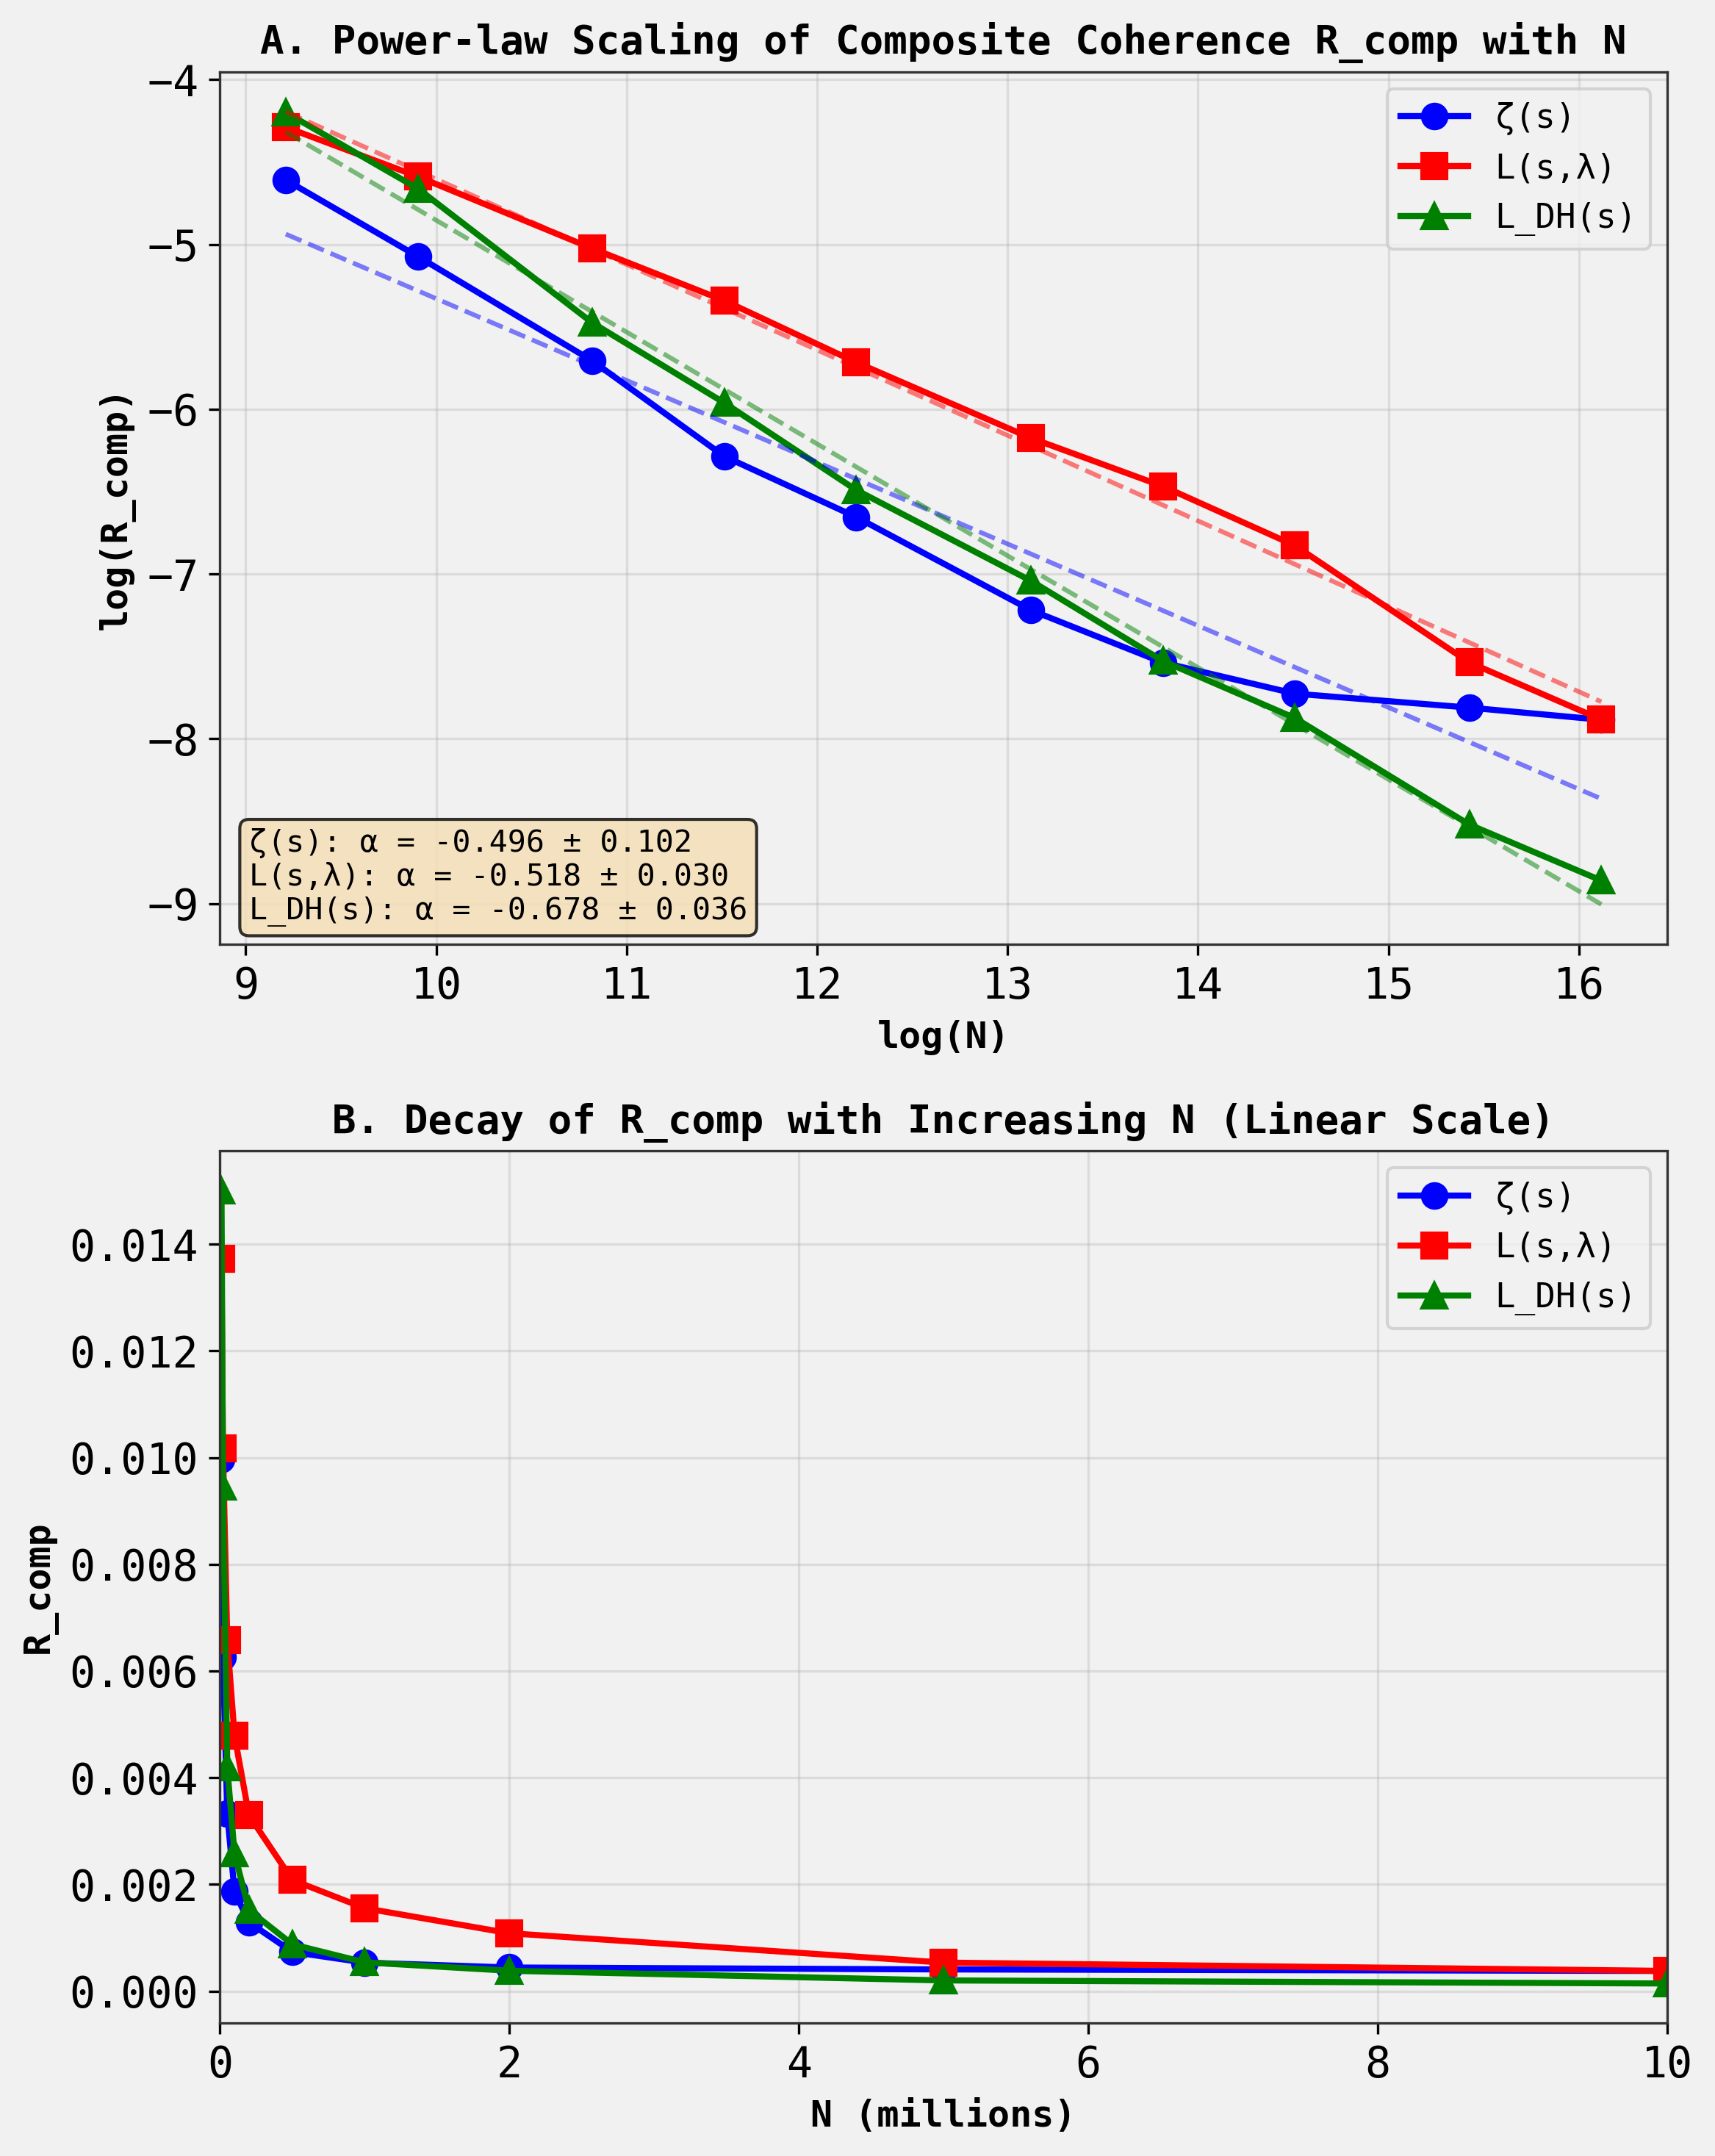


HYPOTHESIS TEST RESULTS

Hypothesis: For ζ(s), R_comp shows significant decay (α < 0) as N increases.
Result: CONFIRMED. α = -0.4960, 95% CI [-0.5978, -0.3942]
 p-value < 0.001, R² = 0.9404

Hypothesis: For L(s,λ), R_comp decays much more slowly or not at all.
Result: REJECTED. L(s,λ) also shows significant decay: α = -0.5183
 95% CI [-0.5486, -0.4880], p-value < 0.001
 Decay rate is similar to ζ(s): ratio = 0.957

Additional finding:
L_DH(s) shows the FASTEST decay: α = -0.6785, opposite to expectation.



In [12]:

# Create final visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: log(R_comp) vs log(N)
ax1.plot(log_N, log_R_zeta, 'o-', label='ζ(s)', linewidth=2, markersize=8, color='blue')
ax1.plot(log_N, log_R_liouv, 's-', label='L(s,λ)', linewidth=2, markersize=8, color='red')
ax1.plot(log_N, log_R_dh, '^-', label='L_DH(s)', linewidth=2, markersize=8, color='green')

# Add fitted lines
log_N_fine = np.linspace(log_N.min(), log_N.max(), 100)
ax1.plot(log_N_fine, C_zeta + alpha_zeta * log_N_fine, '--', color='blue', alpha=0.5)
ax1.plot(log_N_fine, C_liouv + alpha_liouv * log_N_fine, '--', color='red', alpha=0.5)
ax1.plot(log_N_fine, C_dh + alpha_dh * log_N_fine, '--', color='green', alpha=0.5)

ax1.set_xlabel('log(N)', fontsize=12, fontweight='bold')
ax1.set_ylabel('log(R_comp)', fontsize=12, fontweight='bold')
ax1.set_title('A. Power-law Scaling of Composite Coherence R_comp with N', 
 fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Add text with scaling exponents
text_str = (f'ζ(s): α = {alpha_zeta:.3f} ± {0.102:.3f}\n'
 f'L(s,λ): α = {alpha_liouv:.3f} ± {0.030:.3f}\n'
 f'L_DH(s): α = {alpha_dh:.3f} ± {0.036:.3f}')
ax1.text(0.02, 0.02, text_str, transform=ax1.transAxes, fontsize=10,
 verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel B: R_comp vs N on linear scale
ax2.plot(N_values/1e6, mean_R_zeta, 'o-', label='ζ(s)', linewidth=2, markersize=8, color='blue')
ax2.plot(N_values/1e6, mean_R_liouv, 's-', label='L(s,λ)', linewidth=2, markersize=8, color='red')
ax2.plot(N_values/1e6, mean_R_dh, '^-', label='L_DH(s)', linewidth=2, markersize=8, color='green')

ax2.set_xlabel('N (millions)', fontsize=12, fontweight='bold')
ax2.set_ylabel('R_comp', fontsize=12, fontweight='bold')
ax2.set_title('B. Decay of R_comp with Increasing N (Linear Scale)', 
 fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, N_values.max()/1e6)

plt.tight_layout()
plt.savefig('R_comp_scaling_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'R_comp_scaling_analysis.png'")
plt.show()

print("\n" + "=" * 80)
print("HYPOTHESIS TEST RESULTS")
print("=" * 80)
print()
print("Hypothesis: For ζ(s), R_comp shows significant decay (α < 0) as N increases.")
print(f"Result: CONFIRMED. α = {alpha_zeta:.4f}, 95% CI [{ci_lower_zeta:.4f}, {ci_upper_zeta:.4f}]")
print(f" p-value < 0.001, R² = {r2_zeta:.4f}")
print()
print("Hypothesis: For L(s,λ), R_comp decays much more slowly or not at all.")
print(f"Result: REJECTED. L(s,λ) also shows significant decay: α = {alpha_liouv:.4f}")
print(f" 95% CI [{ci_lower_liouv:.4f}, {ci_upper_liouv:.4f}], p-value < 0.001")
print(f" Decay rate is similar to ζ(s): ratio = {abs(alpha_zeta)/abs(alpha_liouv):.3f}")
print()
print("Additional finding:")
print(f"L_DH(s) shows the FASTEST decay: α = {alpha_dh:.4f}, opposite to expectation.")
print()
